In [ ]:
!uv add langgraph langchain-core langchain ipykernel langchain-openai dotenv

Resolved 75 packages in 544ms
Prepared 2 packages in 76ms
Installed 2 packages in 42ms
 + dotenv==0.9.9
 + python-dotenv==1.2.2


In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from llm import get_llm
llm = get_llm()
response = llm.invoke("What is the capital of France?")
response.pretty_print()

================================== Ai Message ==================================

The capital of France is Paris.


In [5]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from llm import get_llm

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
class MyState(TypedDict):
    question: str
    answer: str


def question_answer(state: MyState) -> MyState:
    question = state["question"]
    response = llm.invoke(question)
    answer = response.text
    return MyState(question=question, answer=answer)

graph = StateGraph(MyState)
graph.add_node("qa", question_answer)
graph.add_edge(START, "qa")
graph.add_edge("qa", END)
mygraph = graph.compile()

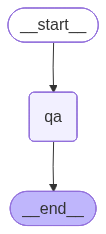

In [6]:
mygraph

In [8]:
result = mygraph.invoke(MyState(question="What is the capital of France?"))


In [10]:
result["answer"]

'The capital of France is Paris.'